In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import bandpass as bp
import covariance as cov
import model
import utils as ut

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u

from pixell import colorize
colorize.mpl_register("planck")

In [5]:
def map_maker_improved(mcmc_fname, cf_name, labels, labels_no_tex, burnin=1, thin=1, 
                       plot_converge=False, print_cf=False, plot_samples=False):
    
    from astropy import units as u
    from astropy.visualization.wcsaxes import SphericalCircle
    
    # Read chain samples and print diagnostics
    sampler = emcee.backends.HDFBackend(mcmc_fname)
    samples = sampler.get_chain(discard=burnin, flat=True, thin=thin)  
    samples_unflat = sampler.get_chain(discard=burnin)
    acc_frac = sampler.accepted / sampler.iteration
    
    print("*Average acceptance fraction is: {:.2f}%".format(np.mean(acc_frac)*100))
    
    ndim = len(labels)
    plt.rc('text', usetex=True)
    plt.rc('font', family='sans-serif', size=20)
    print("\nNumber of iterations: {:.0f}".format(samples.shape[0] / sampler.shape[0]))
    if plot_converge:
        print("Convergence plot")
        converge_plot(sampler, labels)
    
    cf = ut.get_config_file(cf_name)
    if print_cf:
        for key, value in cf.items():
            print(key, ":", value)    
    # Get region and common WCS from a reference ACT map
    region = ut.get_region(cf['region_center_ra'], cf['region_center_dec'], cf['region_width'])
    dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
    dire_data_planck = "/home/gill/research/ACT/bridge/data_paper/data/data/planck_no_reproj"
   
    # Use one ACT map as the reference for Wcs and data_shape
    data_ref = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                                               box=region))
    
    data_wcs = data_ref.wcs
    data_shape = data_ref.shape

    # Compute theta from samples (for all parameters, here for each label)
    theta = []
    for idx, label in enumerate(labels):
        mcmc_run = np.percentile(samples[:, idx], [16, 50, 84])
        err = 0.5 * (mcmc_run[2] - mcmc_run[0])

        data = samples[:, idx]
        n = len(data)
        iqr = np.percentile(data, 75) - np.percentile(data, 25)
        bin_width = 2 * iqr * n**(-1/3)
        num_bins = int((np.max(data) - np.min(data)) / bin_width)
        hist, bin_edges = np.histogram(data, bins=num_bins, density=True)
        mode_bin = np.argmax(hist)
        mode_value = 0.5*(bin_edges[mode_bin] + bin_edges[mode_bin+1])

        theta.append(mcmc_run[1])  # Use median as theta

        print("{}: {:.6f}, +/- {:.6f}".format(label, mcmc_run[1], err))
    
    # Prepare cluster and filament models
    c1 = model.Cluster(theta=theta, name="abell401", model_choice="fit_vavg")
    c2 = model.Cluster(theta=theta, name="abell399", model_choice="fit_vavg")
    fil = model.Filament(theta=theta, model_choice="fit_vavg")

    ra_c1_idx = 0
    dec_c1_idx = 1
    ra_c2_idx = 10
    dec_c2_idx = 11
    ra_fil_idx = 20
    dec_fil_idx = 21

    ra_c1_fit = theta[ra_c1_idx]
    dec_c1_fit = theta[dec_c1_idx]
    ra_c2_fit = theta[ra_c2_idx]
    dec_c2_fit = theta[dec_c2_idx]
    ra_fil_fit = theta[ra_fil_idx]
    dec_fil_fit = theta[dec_fil_idx]

    # Set up frequency-dependent dictionary: keys as string frequencies
        # Set up frequency-dependent dictionary: keys as string frequencies
    freqs_params = {

        '30_npipe': {'freq':30, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
                    'file':"planck_npipe_030_coadd_map_srcfree.fits"},
        '44_npipe': {'freq':44, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
                    'file':"planck_npipe_044_coadd_map_srcfree.fits"},
        '70_npipe': {'freq':70, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
                    'file':"planck_npipe_070_coadd_map_srcfree.fits"},
        '100_npipe':{'freq':100, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
                    'file':"planck_npipe_100_coadd_map_srcfree.fits"},
        '143_npipe':{'freq':143, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
                    'file':"planck_npipe_143_coadd_map_srcfree.fits"},
        '217_npipe':{'freq':217, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
                    'file':"planck_npipe_217_coadd_map_srcfree.fits"},
        '353_npipe':{'freq':353, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
                    'file':"planck_npipe_353_coadd_map_srcfree.fits"},
        '545_npipe':{'freq':545, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
                    'file':"planck_npipe_545_coadd_map_srcfree.fits"},

        '98_pa5': {'freq':98,  'array':'pa5',  'inst':'act',     'dir':dire_data, 
                    'file':"act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits"},
        '98_pa6': {'freq':98,  'array':'pa6',  'inst':'act',     'dir':dire_data, 
                            'file':"act_cut_dr6v2_pa6_f098_4way_coadd_map_srcfree.fits"},

        '150_pa5':{'freq':150, 'array':'pa5',  'inst':'act',     'dir':dire_data, 
                    'file':"act_cut_dr6v2_pa5_f150_4way_coadd_map_srcfree.fits"},
        '150_pa4': {'freq':150, 'array':'pa4',  'inst':'act',     'dir':dire_data, 
                                'file':"act_cut_dr6v2_pa4_f150_4way_coadd_map_srcfree.fits"},
        '150_pa6': {'freq':150, 'array':'pa6',  'inst':'act',     'dir':dire_data, 
                                'file':"act_cut_dr6v2_pa6_f150_4way_coadd_map_srcfree.fits"},
        '220_pa4':{'freq':220, 'array':'pa4',  'inst':'act',     'dir':dire_data, 
                    'file':"act_cut_dr6v2_pa4_f220_4way_coadd_map_srcfree.fits"}
    }
        
    # Containers for results that will be used for plotting later
    ref_data_dict = {}
    model_tot_dict = {}
    c1_sz_signals = {}
    c2_sz_signals = {}
    fil_sz_signals = {}
    c1_dust_signals = {}
    c2_dust_signals = {}
    fil_dust_signals = {}

    ref_data_dict_uK = {}
    model_tot_dict_uK = {}

    total_sz_signals = {}
    
    # Create common grid (assumed same for all frequencies)
    xgrid, ygrid = np.meshgrid(np.arange(data_shape[1]), np.arange(data_shape[0]))
    
    # Loop over frequencies
    for key, params in freqs_params.items():
        freq = params['freq']
        array = params['array']
        inst = params['inst']
        map_file = f"{params['dir']}/{params['file']}"
        
        ref_map = enmap.read_map(map_file, box=region)
        ref_data_curr = ut.imap_dim_check(ref_map)
        # Multiply by flux factor
        flux_factor = ut.flux_factor(array, freq)
        ref_data_curr *= flux_factor
        
        # Build SZ models using the same grid
        c1_model = c1.szmodel(frequency=freq, array=array, z=cf['c1_z'], muo=cf['c1_muo'],
                               xgrid=xgrid, ygrid=ygrid, ellipticity_type="numerator")
        c2_model = c2.szmodel(frequency=freq, array=array, z=cf['c2_z'], muo=cf['c2_muo'],
                               xgrid=xgrid, ygrid=ygrid, ellipticity_type="numerator")
        fil_model = fil.szmodel(frequency=freq, array=array, z=cf['fil_z'], muo=cf['fil_muo'],
                                 xgrid=xgrid, ygrid=ygrid)
        
        # CHANGE HERE
        #total_model = c1_model[0] + c2_model[0] 
        total_model = fil_model[0]

        # Convolve with beam
        beam = ut.get_2d_beam(data_shape=ref_data_curr.shape, freq=freq, array=array, 
                              inst=inst, version="dr6v2", data_wcs=data_wcs)
        model_tot = np.real(np.fft.ifft2(np.fft.fft2(total_model) * beam))

        # convert model to microK
        model_tot_microK = model_tot / flux_factor
        ref_data_curr_microK = ref_data_curr / flux_factor

        # Get SZ signals at the set (RA,Dec) pixel
        c1_model_SZ = enmap.ndmap(c1_model[1], data_ref.wcs)
        dust_model_SZ = enmap.ndmap(c1_model[2], data_ref.wcs)
        c1_signal_sz = c1_model_SZ.at([dec_c1_fit, ra_c1_fit], unit="pix")
        c1_signal_dust = dust_model_SZ.at([dec_c1_fit, ra_c1_fit], unit="pix")

        c2_model_SZ = enmap.ndmap(c2_model[1], data_ref.wcs)
        dust_model_SZ = enmap.ndmap(c2_model[2], data_ref.wcs)
        c2_signal_sz = c2_model_SZ.at([dec_c2_fit, ra_c2_fit], unit="pix")
        c2_signal_dust = dust_model_SZ.at([dec_c2_fit, ra_c2_fit], unit="pix")

        fil_model_SZ = enmap.ndmap(fil_model[1], data_ref.wcs)
        dust_model_SZ = enmap.ndmap(fil_model[2], data_ref.wcs)
        fil_signal_sz = fil_model_SZ.at([dec_fil_fit, ra_fil_fit], unit="pix")
        fil_signal_dust = dust_model_SZ.at([dec_fil_fit, ra_fil_fit], unit="pix")
        
        # Save into dictionaries
        ref_data_dict[key] = ref_data_curr
        model_tot_dict[key] = model_tot
        c1_sz_signals[key] = c1_signal_sz
        c2_sz_signals[key] = c2_signal_sz
        fil_sz_signals[key] = fil_signal_sz
        c1_dust_signals[key] = c1_signal_dust
        c2_dust_signals[key] = c2_signal_dust
        fil_dust_signals[key] = fil_signal_dust

        model_tot_dict_uK[key] = model_tot_microK
        ref_data_dict_uK[key] = ref_data_curr_microK

    # make a dictionary with vmin and vmax for each frequency
    vmin_vmax_dict = {}

    vmin_vmax_dict['30'] = {'vmin': -10, 'vmax': 10}
    vmin_vmax_dict['44'] = {'vmin': -15, 'vmax': 15}
    vmin_vmax_dict['70'] = {'vmin': -50, 'vmax': 50}
    vmin_vmax_dict['98'] = {'vmin': -60, 'vmax': 60}
    vmin_vmax_dict['100'] = {'vmin': -100, 'vmax': 100}
    vmin_vmax_dict['143'] = {'vmin': -150, 'vmax': 150}
    vmin_vmax_dict['150'] = {'vmin': -150, 'vmax': 150}
    vmin_vmax_dict['217'] = {'vmin': -300, 'vmax': 300}
    vmin_vmax_dict['220'] = {'vmin': -300, 'vmax': 300}
    vmin_vmax_dict['353'] = {'vmin': -1000, 'vmax': 1000}
    vmin_vmax_dict['545'] = {'vmin': 0, 'vmax': 3000}

    vmin_vmax_model_dict = {
        '30': {'vmin': -2, 'vmax': 2},
        '44': {'vmin': -6, 'vmax': 6},
        '70': {'vmin': -25, 'vmax': 25},
        '98': {'vmin': -80, 'vmax': 80},
        '100': {'vmin': -35, 'vmax': 35},
        '143': {'vmin': -40, 'vmax': 40},
        '150': {'vmin': -40, 'vmax': 40},
        '217': {'vmin': -30, 'vmax': 30},
        '220': {'vmin': -30, 'vmax': 30},
        '353': {'vmin': 0, 'vmax': 500},
        '545': {'vmin': 0, 'vmax': 500}
    }

    beam_fwhm_dict = {
        '30': 32.4, 
        '44': 27.1, 
        '70': 13.3,
        '98': 2.1, 
        '100': 9.7, 
        '143': 7.3,
        '150': 1.4, 
        '217': 5.0, 
        '220': 1.0,
        '353': 4.9, 
        '545': 4.60
    } # units of arcmin
        
    # PLOTTING: Define instruments and array mapping for plot titles
    inst_dict = {'98':"ACT", "150":"ACT", "220":"ACT", 
                 "30":"Planck", "44":"Planck", "70":"Planck",
                 "100":"Planck", "143":"Planck", 
                 "217":"Planck", "353": "Planck", "545":"Planck"}
    array_dict = {'98':'pa5', "150":'pa5', "220":'pa4',
                  "30":'npipe', "44":'npipe', "70":'npipe',
                  "100":'npipe', "143":'npipe', "217":'npipe',
                  "353":'npipe', "545":'npipe'}
    
    # Order for plotting (only those keys present in freqs_params)
    plot_keys = ['30','44','70','98','100','143','150','217','220','353','545']
    
    for key, params in freqs_params.items():
        # Skip any frequencies not processed
        if key not in ref_data_dict:
            print(f"Skipping {key} GHz as it is not processed.")
            continue
        
        # Get data for this frequency
        ref_data_curr = ref_data_dict[key]  # Convert to Jy/sr
        model_tot = model_tot_dict[key]     # Convert to Jy/sr
        residual = ref_data_curr - model_tot

        model_tot_microK = model_tot_dict_uK[key] # uK
        ref_data_curr_microK = ref_data_dict_uK[key] # uK
        residual_microK = ref_data_curr_microK - model_tot_microK   

        vmin = None
        vmax = None
        vmin_model = None    
        vmax_model = None    
        
        # Create figure with individual subplots for better control
        fig = plt.figure(figsize=(15, 5))
        
        # Data panel
        ax1 = fig.add_subplot(131, projection=data_ref.wcs)
        im1 = ax1.imshow(ref_data_curr, origin='lower', cmap='planck', 
                         vmin=vmin, vmax=vmax, interpolation='none')
        ax1.coords[0].set_axislabel('Right Ascension')
        ax1.coords[1].set_axislabel('Declination')
        ax1.coords[0].set_major_formatter('d')
        ax1.coords[1].set_major_formatter('d')
        ax1.invert_xaxis()
        ax1.set_title(f'Data: {key} GHz', fontsize=20, pad=20)
        
        # Add beam circle to data panel
        beam_radius_arcmin = beam_fwhm_dict[key.split('_')[0]] / 2
        # Calculate offset based on beam size (larger beams get larger offsets)
        # Scale the offset with beam size, with a minimum offset for small beams
        ra0, dec0 = cf['region_center_ra'] - 0.7, cf['region_center_dec'] + 0.7

        sky_center = SkyCoord(ra0, dec0, unit='deg', frame='icrs')

        beam_circle = SphericalCircle(sky_center, beam_radius_arcmin * u.arcmin,
                                transform=ax1.get_transform('icrs'),
                               edgecolor='black', facecolor='none', linewidth=2)
        ax1.add_patch(beam_circle)

        # Model panel
        ax2 = fig.add_subplot(132, projection=data_ref.wcs)
        im2 = ax2.imshow(model_tot, origin='lower', cmap='planck', 
                         vmin=vmin_model, vmax=vmax_model, interpolation='none')
        ax2.coords[0].set_axislabel('Right Ascension')
        ax2.coords[1].set_axislabel('Declination')
        ax2.coords[0].set_major_formatter('d')
        ax2.coords[1].set_major_formatter('d')
        ax2.invert_xaxis()
        ax2.set_title(f'Model: {key} GHz', fontsize=20, pad=20)
        
        # Add beam circle to model panel
        beam_circle = SphericalCircle(sky_center, beam_radius_arcmin * u.arcmin,
                        transform=ax2.get_transform('icrs'),
                       edgecolor='black', facecolor='none', linewidth=2)
        ax2.add_patch(beam_circle)
        
        # Residual panel
        ax3 = fig.add_subplot(133, projection=data_ref.wcs)
        im3 = ax3.imshow(residual, origin='lower', cmap='planck', 
                 vmin=vmin, vmax=vmax, interpolation='none')
        ax3.coords[0].set_axislabel('Right Ascension')
        ax3.coords[1].set_axislabel('Declination')
        ax3.coords[0].set_major_formatter('d')
        ax3.coords[1].set_major_formatter('d')
        ax3.invert_xaxis()
        ax3.set_title(f'Residual: {key} GHz', fontsize=20, pad=20)
        
        # Add beam circle to residual panel
        beam_circle = SphericalCircle(sky_center, beam_radius_arcmin * u.arcmin,
                        transform=ax3.get_transform('icrs'),
                       edgecolor='black', facecolor='none', linewidth=2)
        ax3.add_patch(beam_circle)
        
        # Add colorbars
        plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.25, 
                     label=r'$I$ [kJy/sr]', fraction=0.046)
        plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.25, 
                     label=r'$I$ [kJy/sr]', fraction=0.046)
        plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.25, 
                     label=r'$I$ [kJy/sr]', fraction=0.046)
    
        ref_data_curr = enmap.ndmap(ref_data_curr, data_ref.wcs)
        model_tot = enmap.ndmap(model_tot, data_ref.wcs)
        residual = enmap.ndmap(residual, data_ref.wcs)
    
        ref_data_curr_microK = enmap.ndmap(ref_data_curr_microK, data_ref.wcs)
        model_tot_microK = enmap.ndmap(model_tot_microK, data_ref.wcs)
        residual_microK = enmap.ndmap(residual_microK, data_ref.wcs)
    
        #plt.savefig(f"../plots/bridge_indv_{key}.pdf", bbox_inches='tight', dpi=300, format='pdf')
        plt.show()

        # save Jy signals
        print(f"Saving maps for {key} GHz")
        dire_save = "/home/gill/research/ACT/paper/models/indiv/july30/total_model_all_three_systems_small_map/filament/"
        enmap.write_map(f"{dire_save}/maps/bridge_indv_{key}_data_Jy.fits", ref_data_curr)
        enmap.write_map(f"{dire_save}/models/bridge_indv_{key}_model_Jy.fits", model_tot)
        enmap.write_map(f"{dire_save}/residuals/bridge_indv_{key}_residual_Jy.fits", residual)

        # save uK signals
        enmap.write_map(f"{dire_save}/maps/bridge_indv_{key}_data_uK.fits", ref_data_curr_microK)
        enmap.write_map(f"{dire_save}/models/bridge_indv_{key}_model_uK.fits", model_tot_microK)
        enmap.write_map(f"{dire_save}/residuals/bridge_indv_{key}_residual_uK.fits", residual_microK)
    

In [6]:
# def map_maker_improved_fullSize(mcmc_fname, cf_name, labels, labels_no_tex, burnin=1, thin=1, 
#                        plot_converge=False, print_cf=False, plot_samples=False):
    
#     from astropy import units as u
#     from astropy.visualization.wcsaxes import SphericalCircle
    
#     # Read chain samples and print diagnostics
#     sampler = emcee.backends.HDFBackend(mcmc_fname)
#     samples = sampler.get_chain(discard=burnin, flat=True, thin=thin)  
#     samples_unflat = sampler.get_chain(discard=burnin)
#     acc_frac = sampler.accepted / sampler.iteration
    
#     print("*Average acceptance fraction is: {:.2f}%".format(np.mean(acc_frac)*100))
    
#     ndim = len(labels)
#     plt.rc('text', usetex=True)
#     plt.rc('font', family='sans-serif', size=20)
#     print("\nNumber of iterations: {:.0f}".format(samples.shape[0] / sampler.shape[0]))
#     if plot_converge:
#         print("Convergence plot")
#         converge_plot(sampler, labels)
    
#     cf = ut.get_config_file(cf_name)
#     if print_cf:
#         for key, value in cf.items():
#             print(key, ":", value)    
#     # Get region and common WCS from a reference ACT map
#     region = ut.get_region(cf['region_center_ra'], cf['region_center_dec'], cf['region_width'])
#     dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
#     dire_data_planck = "/home/gill/research/ACT/bridge/data_paper/data/data/planck_no_reproj"
   
#     # Use one ACT map as the reference for Wcs and data_shape
#     data_ref = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits"))
    
#     data_wcs = data_ref.wcs
#     data_shape = data_ref.shape

#     # Compute theta from samples (for all parameters, here for each label)
#     theta = []
#     for idx, label in enumerate(labels):
#         mcmc_run = np.percentile(samples[:, idx], [16, 50, 84])
#         err = 0.5 * (mcmc_run[2] - mcmc_run[0])

#         data = samples[:, idx]
#         n = len(data)
#         iqr = np.percentile(data, 75) - np.percentile(data, 25)
#         bin_width = 2 * iqr * n**(-1/3)
#         num_bins = int((np.max(data) - np.min(data)) / bin_width)
#         hist, bin_edges = np.histogram(data, bins=num_bins, density=True)
#         mode_bin = np.argmax(hist)
#         mode_value = 0.5*(bin_edges[mode_bin] + bin_edges[mode_bin+1])

#         theta.append(mcmc_run[1])  # Use median as theta

#         print("{}: {:.6f}, +/- {:.6f}".format(label, mcmc_run[1], err))

#     # Prepare cluster and filament models
#     RA_A401 = 44.741
#     DEC_A401 = 13.580

#     RA_A399 = 44.465
#     DEC_A399 = 13.040

#     RA_Fil = 44.669
#     DEC_Fil = 13.342    

#     # convert to pixels
#     RA_A401_pix = data_ref.wcs.celestial.wcs_world2pix(RA_A401, DEC_A401, 0)[0]
#     DEC_A401_pix = data_ref.wcs.celestial.wcs_world2pix(RA_A401, DEC_A401, 0)[1]

#     RA_A399_pix = data_ref.wcs.celestial.wcs_world2pix(RA_A399, DEC_A399, 0)[0]
#     DEC_A399_pix = data_ref.wcs.celestial.wcs_world2pix(RA_A399, DEC_A399, 0)[1]

#     RA_Fil_pix = data_ref.wcs.celestial.wcs_world2pix(RA_Fil, DEC_Fil, 0)[0]
#     DEC_Fil_pix = data_ref.wcs.celestial.wcs_world2pix(RA_Fil, DEC_Fil, 0)[1]

#     ra_401_idx = 0
#     dec_401_idx = 1
#     ra_399_idx = 10
#     dec_399_idx = 11
#     ra_fil_idx = 20
#     dec_fil_idx = 21

#     # change theta at the indices of the RA and DEC of the clusters and filament
#     theta[ra_401_idx] = RA_A401_pix
#     theta[dec_401_idx] = DEC_A401_pix
#     theta[ra_399_idx] = RA_A399_pix
#     theta[dec_399_idx] = DEC_A399_pix
#     theta[ra_fil_idx] = RA_Fil_pix
#     theta[dec_fil_idx] = DEC_Fil_pix
    
#     # Prepare cluster and filament models
#     c1 = model.Cluster(theta=theta, name="abell401", model_choice="fit_vavg")
#     c2 = model.Cluster(theta=theta, name="abell399", model_choice="fit_vavg")
#     fil = model.Filament(theta=theta, model_choice="fit_vavg")

#     ra_c1_idx = 0
#     dec_c1_idx = 1
#     ra_c2_idx = 10
#     dec_c2_idx = 11
#     ra_fil_idx = 20
#     dec_fil_idx = 21

#     ra_c1_fit = theta[ra_c1_idx]
#     dec_c1_fit = theta[dec_c1_idx]
#     ra_c2_fit = theta[ra_c2_idx]
#     dec_c2_fit = theta[dec_c2_idx]
#     ra_fil_fit = theta[ra_fil_idx]
#     dec_fil_fit = theta[dec_fil_idx]

#         # Set up frequency-dependent dictionary: keys as string frequencies
#     freqs_params = {

#         '30_npipe': {'freq':30, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
#                     'file':"planck_npipe_030_coadd_map_srcfree.fits"},
#         '44_npipe': {'freq':44, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
#                     'file':"planck_npipe_044_coadd_map_srcfree.fits"},
#         '70_npipe': {'freq':70, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
#                     'file':"planck_npipe_070_coadd_map_srcfree.fits"},
#         '100_npipe':{'freq':100, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
#                     'file':"planck_npipe_100_coadd_map_srcfree.fits"},
#         '143_npipe':{'freq':143, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
#                     'file':"planck_npipe_143_coadd_map_srcfree.fits"},
#         '217_npipe':{'freq':217, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
#                     'file':"planck_npipe_217_coadd_map_srcfree.fits"},
#         '353_npipe':{'freq':353, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
#                     'file':"planck_npipe_353_coadd_map_srcfree.fits"},
#         '545_npipe':{'freq':545, 'array':'npipe', 'inst':'planck', 'dir':dire_data_planck, 
#                     'file':"planck_npipe_545_coadd_map_srcfree.fits"},

#         '98_pa5': {'freq':98,  'array':'pa5',  'inst':'act',     'dir':dire_data, 
#                     'file':"act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits"},
#         '98_pa6': {'freq':98,  'array':'pa6',  'inst':'act',     'dir':dire_data, 
#                             'file':"act_cut_dr6v2_pa6_f098_4way_coadd_map_srcfree.fits"},

#         '150_pa5':{'freq':150, 'array':'pa5',  'inst':'act',     'dir':dire_data, 
#                     'file':"act_cut_dr6v2_pa5_f150_4way_coadd_map_srcfree.fits"},
#         '150_pa4': {'freq':150, 'array':'pa4',  'inst':'act',     'dir':dire_data, 
#                                 'file':"act_cut_dr6v2_pa4_f150_4way_coadd_map_srcfree.fits"},
#         '150_pa6': {'freq':150, 'array':'pa6',  'inst':'act',     'dir':dire_data, 
#                                 'file':"act_cut_dr6v2_pa6_f150_4way_coadd_map_srcfree.fits"},
#         '220_pa4':{'freq':220, 'array':'pa4',  'inst':'act',     'dir':dire_data, 
#                     'file':"act_cut_dr6v2_pa4_f220_4way_coadd_map_srcfree.fits"}
#     }
        
#     # Containers for results that will be used for plotting later
#     ref_data_dict = {}
#     model_tot_dict = {}
#     c1_sz_signals = {}
#     c2_sz_signals = {}
#     fil_sz_signals = {}
#     c1_dust_signals = {}
#     c2_dust_signals = {}
#     fil_dust_signals = {}

#     ref_data_dict_uK = {}
#     model_tot_dict_uK = {}

#     total_sz_signals = {}
    
#     # Create common grid (assumed same for all frequencies)
#     xgrid, ygrid = np.meshgrid(np.arange(data_shape[1]), np.arange(data_shape[0]))
    
#     # Loop over frequencies
#     for key, params in freqs_params.items():
#         freq = params['freq']
#         array = params['array']
#         inst = params['inst']
#         map_file = f"{params['dir']}/{params['file']}"
        
#         ref_map = enmap.read_map(map_file)
#         ref_data_curr = ut.imap_dim_check(ref_map)
#         flux_factor = ut.flux_factor(array, freq)
#         ref_data_curr *= flux_factor
        
#         # Build SZ models using the same grid
#         c1_model = c1.szmodel(frequency=freq, array=array, z=cf['c1_z'], muo=cf['c1_muo'],
#                                xgrid=xgrid, ygrid=ygrid, ellipticity_type="numerator")
#         c2_model = c2.szmodel(frequency=freq, array=array, z=cf['c2_z'], muo=cf['c2_muo'],
#                                xgrid=xgrid, ygrid=ygrid, ellipticity_type="numerator")
#         fil_model = fil.szmodel(frequency=freq, array=array, z=cf['fil_z'], muo=cf['fil_muo'],
#                                  xgrid=xgrid, ygrid=ygrid)
        
#         #total_model = c1_model[0] + c2_model[0] + fil_model[0]

#         total_model = c1_model[0] + c2_model[0] 
        
#         # Convolve with beam
#         beam = ut.get_2d_beam(data_shape=ref_data_curr.shape, freq=freq, array=array, 
#                               inst=inst, version="dr6v2", data_wcs=data_wcs)
#         model_tot = np.real(np.fft.ifft2(np.fft.fft2(total_model) * beam))

#         # convert model to microK
#         model_tot_microK = model_tot / flux_factor
#         ref_data_curr_microK = ref_data_curr / flux_factor

#         # Get SZ signals at the set (RA,Dec) pixel
#         c1_model_SZ = enmap.ndmap(c1_model[1], data_ref.wcs)
#         dust_model_SZ = enmap.ndmap(c1_model[2], data_ref.wcs)
#         c1_signal_sz = c1_model_SZ.at([dec_c1_fit, ra_c1_fit], unit="pix")
#         c1_signal_dust = dust_model_SZ.at([dec_c1_fit, ra_c1_fit], unit="pix")

#         c2_model_SZ = enmap.ndmap(c2_model[1], data_ref.wcs)
#         dust_model_SZ = enmap.ndmap(c2_model[2], data_ref.wcs)
#         c2_signal_sz = c2_model_SZ.at([dec_c2_fit, ra_c2_fit], unit="pix")
#         c2_signal_dust = dust_model_SZ.at([dec_c2_fit, ra_c2_fit], unit="pix")

#         fil_model_SZ = enmap.ndmap(fil_model[1], data_ref.wcs)
#         dust_model_SZ = enmap.ndmap(fil_model[2], data_ref.wcs)
#         fil_signal_sz = fil_model_SZ.at([dec_fil_fit, ra_fil_fit], unit="pix")
#         fil_signal_dust = dust_model_SZ.at([dec_fil_fit, ra_fil_fit], unit="pix")
        
#         # Save into dictionaries
#         ref_data_dict[key] = ref_data_curr
#         model_tot_dict[key] = model_tot
#         c1_sz_signals[key] = c1_signal_sz
#         c2_sz_signals[key] = c2_signal_sz
#         fil_sz_signals[key] = fil_signal_sz
#         c1_dust_signals[key] = c1_signal_dust
#         c2_dust_signals[key] = c2_signal_dust
#         fil_dust_signals[key] = fil_signal_dust
#         model_tot_dict_uK[key] = model_tot_microK
#         ref_data_dict_uK[key] = ref_data_curr_microK

#     # make a dictionary with vmin and vmax for each frequency
#     vmin_vmax_dict = {}

#     vmin_vmax_dict['30'] = {'vmin': -10, 'vmax': 10}
#     vmin_vmax_dict['44'] = {'vmin': -15, 'vmax': 15}
#     vmin_vmax_dict['70'] = {'vmin': -50, 'vmax': 50}
#     vmin_vmax_dict['98'] = {'vmin': -60, 'vmax': 60}
#     vmin_vmax_dict['100'] = {'vmin': -100, 'vmax': 100}
#     vmin_vmax_dict['143'] = {'vmin': -150, 'vmax': 150}
#     vmin_vmax_dict['150'] = {'vmin': -150, 'vmax': 150}
#     vmin_vmax_dict['217'] = {'vmin': -300, 'vmax': 300}
#     vmin_vmax_dict['220'] = {'vmin': -300, 'vmax': 300}
#     vmin_vmax_dict['353'] = {'vmin': -1000, 'vmax': 1000}
#     vmin_vmax_dict['545'] = {'vmin': 0, 'vmax': 3000}

#     vmin_vmax_model_dict = {
#         '30': {'vmin': -2, 'vmax': 2},
#         '44': {'vmin': -6, 'vmax': 6},
#         '70': {'vmin': -25, 'vmax': 25},
#         '98': {'vmin': -80, 'vmax': 80},
#         '100': {'vmin': -35, 'vmax': 35},
#         '143': {'vmin': -40, 'vmax': 40},
#         '150': {'vmin': -40, 'vmax': 40},
#         '217': {'vmin': -30, 'vmax': 30},
#         '220': {'vmin': -30, 'vmax': 30},
#         '353': {'vmin': 0, 'vmax': 500},
#         '545': {'vmin': 0, 'vmax': 500}
#     }

#     beam_fwhm_dict = {
#         '30': 32.4, 
#         '44': 27.1, 
#         '70': 13.3,
#         '98': 2.1, 
#         '100': 9.7, 
#         '143': 7.3,
#         '150': 1.4, 
#         '217': 5.0, 
#         '220': 1.0,
#         '353': 4.9, 
#         '545': 4.60
#     } # units of arcmin
        
#     # PLOTTING: Define instruments and array mapping for plot titles
#     inst_dict = {'98':"ACT", "150":"ACT", "220":"ACT", 
#                  "30":"Planck", "44":"Planck", "70":"Planck",
#                  "100":"Planck", "143":"Planck", 
#                  "217":"Planck", "353": "Planck", "545":"Planck"}
#     array_dict = {'98':'pa5', "150":'pa5', "220":'pa4', "150":"pa4",
#                   "98":"pa6", "150":"pa6",
#                   "30":'npipe', "44":'npipe', "70":'npipe',
#                   "100":'npipe', "143":'npipe', "217":'npipe',
#                   "353":'npipe', "545":'npipe'}
    
#     # Order for plotting (only those keys present in freqs_params)
#     plot_keys = ['30','44','70','98','100','143','150','217','220','353','545']
    
#     for key, params in freqs_params.items():
#        # Skip any frequencies not processed
#        if key not in ref_data_dict:
#            continue
       
#        # Get data for this frequency
#        ref_data_curr = ref_data_dict[key] / 1e3  # Convert to kJy/sr
#        model_tot = model_tot_dict[key] / 1e3     # Convert to kJy/sr
#        residual = ref_data_curr - model_tot
#        model_tot_microK = model_tot_dict_uK[key] # uK
#        ref_data_curr_microK = ref_data_dict_uK[key] # uK
#        residual_microK = ref_data_curr_microK - model_tot_microK

#        vmin = None
#        vmax = None
#        vmin_model = None
#        vmax_model = None
       
#        # Create figure with individual subplots for better control
#        fig = plt.figure(figsize=(15, 5))
       
#        # Data panel
#        ax1 = fig.add_subplot(131, projection=data_ref.wcs)
#        im1 = ax1.imshow(ref_data_curr, origin='lower', cmap='planck', 
#                         vmin=vmin, vmax=vmax, interpolation='none')
#        ax1.coords[0].set_axislabel('Right Ascension')
#        ax1.coords[1].set_axislabel('Declination')
#        ax1.coords[0].set_major_formatter('d')
#        ax1.coords[1].set_major_formatter('d')
#        ax1.invert_xaxis()
#        ax1.set_title(f'Data: {key} GHz', fontsize=20, pad=20)
       
#        # Add beam circle to data panel
#        beam_radius_arcmin = beam_fwhm_dict[key.split('_')[0]] / 2
#        # Calculate offset based on beam size (larger beams get larger offsets)
#        # Scale the offset with beam size, with a minimum offset for small beams
#        ra0, dec0 = cf['region_center_ra'] - 0.7, cf['region_center_dec'] + 0.7
#        sky_center = SkyCoord(ra0, dec0, unit='deg', frame='icrs')
#        beam_circle = SphericalCircle(sky_center, beam_radius_arcmin * u.arcmin,
#                                transform=ax1.get_transform('icrs'),
#                               edgecolor='black', facecolor='none', linewidth=2)
#        ax1.add_patch(beam_circle)
#        # Model panel
#        ax2 = fig.add_subplot(132, projection=data_ref.wcs)
#        im2 = ax2.imshow(model_tot, origin='lower', cmap='planck', 
#                         vmin=vmin_model, vmax=vmax_model, interpolation='none')
#        ax2.coords[0].set_axislabel('Right Ascension')
#        ax2.coords[1].set_axislabel('Declination')
#        ax2.coords[0].set_major_formatter('d')
#        ax2.coords[1].set_major_formatter('d')
#        ax2.invert_xaxis()
#        ax2.set_title(f'Model: {key} GHz', fontsize=20, pad=20)
       
#        # Add beam circle to model panel
#        beam_circle = SphericalCircle(sky_center, beam_radius_arcmin * u.arcmin,
#                        transform=ax2.get_transform('icrs'),
#                       edgecolor='black', facecolor='none', linewidth=2)
#        ax2.add_patch(beam_circle)
       
#        # Residual panel
#        ax3 = fig.add_subplot(133, projection=data_ref.wcs)
#        im3 = ax3.imshow(residual, origin='lower', cmap='planck', 
#                 vmin=vmin, vmax=vmax, interpolation='none')
#        ax3.coords[0].set_axislabel('Right Ascension')
#        ax3.coords[1].set_axislabel('Declination')
#        ax3.coords[0].set_major_formatter('d')
#        ax3.coords[1].set_major_formatter('d')
#        ax3.invert_xaxis()
#        ax3.set_title(f'Residual: {key} GHz', fontsize=20, pad=20)
       
#        # Add beam circle to residual panel
#        beam_circle = SphericalCircle(sky_center, beam_radius_arcmin * u.arcmin,
#                        transform=ax3.get_transform('icrs'),
#                       edgecolor='black', facecolor='none', linewidth=2)
#        ax3.add_patch(beam_circle)
       
#        # Add colorbars
#        plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.25, 
#                     label=r'$I$ [kJy/sr]', fraction=0.046)
#        plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.25, 
#                     label=r'$I$ [kJy/sr]', fraction=0.046)
#        plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.25, 
#                     label=r'$I$ [kJy/sr]', fraction=0.046)
       
#        # plt.tight_layout()
#        #plt.savefig(f"../plots/bridge_indv_{key}.pdf", bbox_inches='tight', dpi=300, format='pdf')
#        plt.show()
#        # save the data, model, and residual maps with WCS information in uK
#        print(f"Saving maps for {key}...")
#        ref_data_curr_microK = enmap.ndmap(ref_data_curr_microK, data_ref.wcs)
#        model_tot_microK = enmap.ndmap(model_tot_microK, data_ref.wcs)
#        residual_microK = enmap.ndmap(residual_microK, data_ref.wcs)
#        dire_save = "/home/gill/research/ACT/paper/models/indiv/total_model_only_clusters_full_map"
#        enmap.write_map(f"{dire_save}/maps/data_{key}.fits", ref_data_curr_microK)
#        enmap.write_map(f"{dire_save}/models/model_{key}.fits", model_tot_microK)
#        enmap.write_map(f"{dire_save}/residuals/residual_{key}.fits", residual_microK)

*Average acceptance fraction is: 20.47%

Number of iterations: 55830
$RA_{\rm A401}$: 143.921134, +/- 0.208689
$DEC_{\rm A401}$: 159.540465, +/- 0.277357
$\beta_{\rm A401}$: 1.267863, +/- 0.090903
$r_{\rm c, A401}$ [$^{\prime}$]: 4.924474, +/- 0.523479
$e_{\rm A401}$: 1.250701, +/- 0.086506
$\theta_{\rm A401}$: 107.436182, +/- 6.606312
$\tau_{\rm A401}$: 0.007208, +/- 0.000480
$T_{\rm e, A401}$: 8.458845, +/- 0.248314
$A_{\rm D, A401}$: 240941.038106, +/- 200246.408123
$v_{r, A401}$: -1074.630940, +/- 716.383932
$RA_{\rm A399}$: 110.743892, +/- 0.379566
$DEC_{\rm A399}$: 94.795893, +/- 0.423726
$\beta_{\rm A399}$: 1.017510, +/- 0.068290
$r_{\rm c, A399}$ [$^{\prime}$]: 4.002189, +/- 0.539870
$e_{\rm A399}$: 1.100522, +/- 0.110169
$\theta_{\rm A399}$: 109.819243, +/- 27.119532
$\tau_{\rm A399}$: 0.006506, +/- 0.000465
$T_{\rm e, A399}$: 7.227089, +/- 0.185465
$A_{\rm D, A399}$: 145748.374016, +/- 148713.891739
$v_{r, A399}$: 646.133848, +/- 682.266609
$RA_{\rm fil}$: 135.299228, +/- 2.5

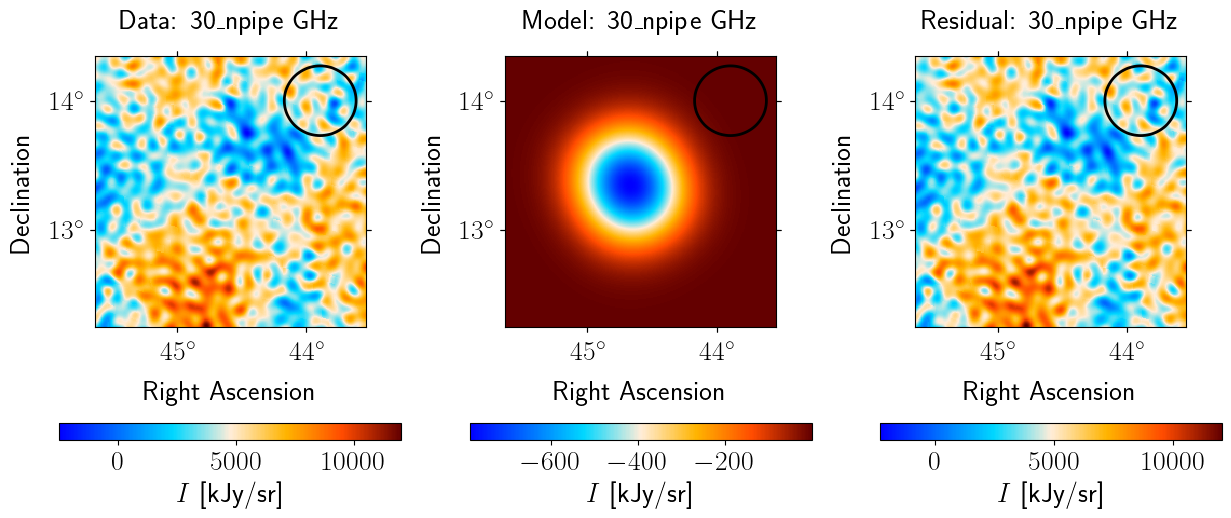

Saving maps for 30_npipe GHz


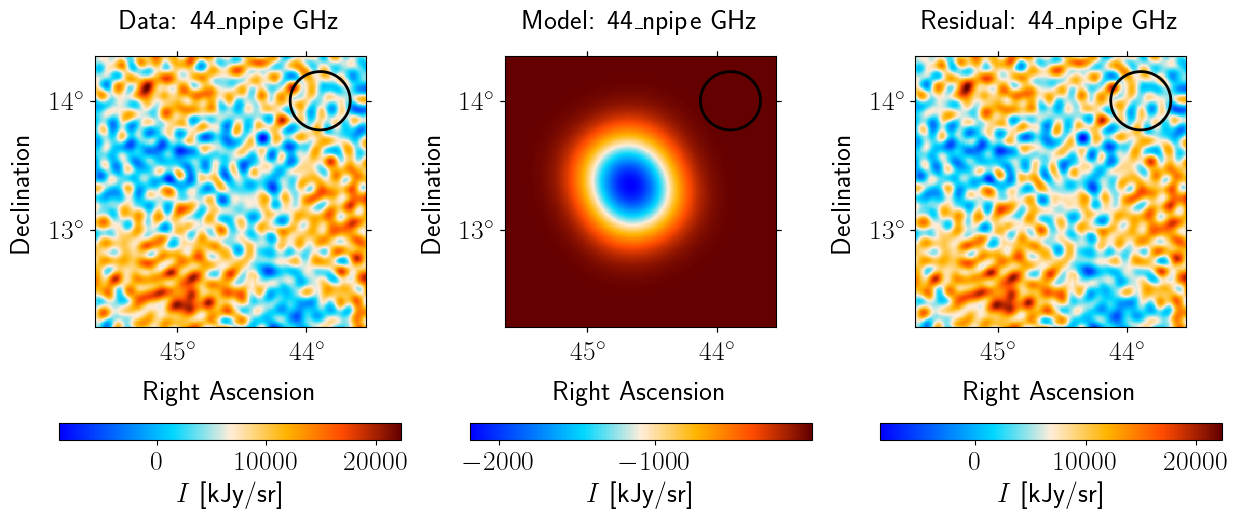

Saving maps for 44_npipe GHz


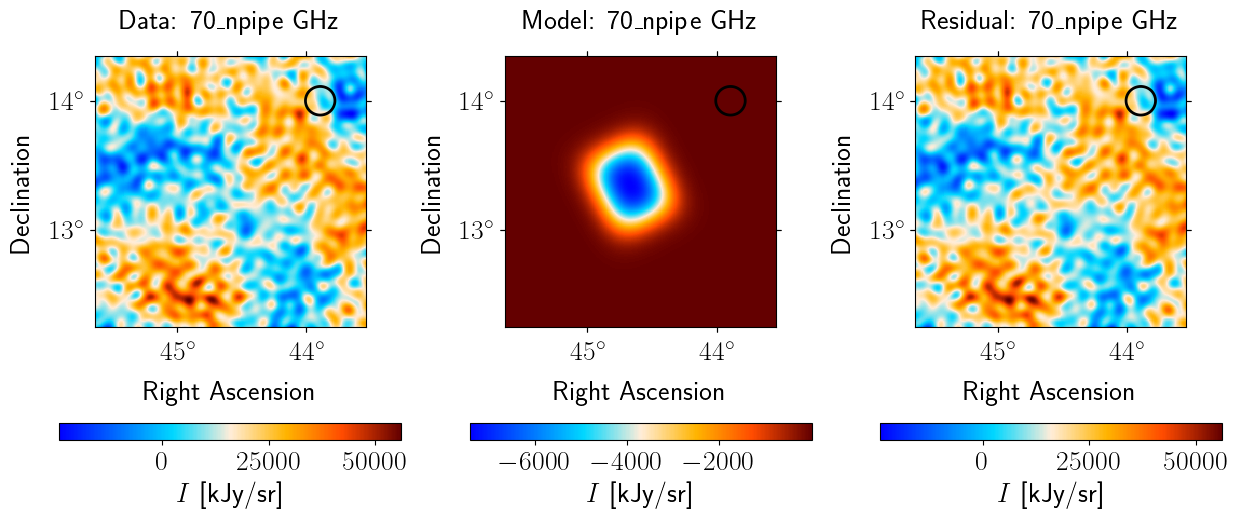

Saving maps for 70_npipe GHz


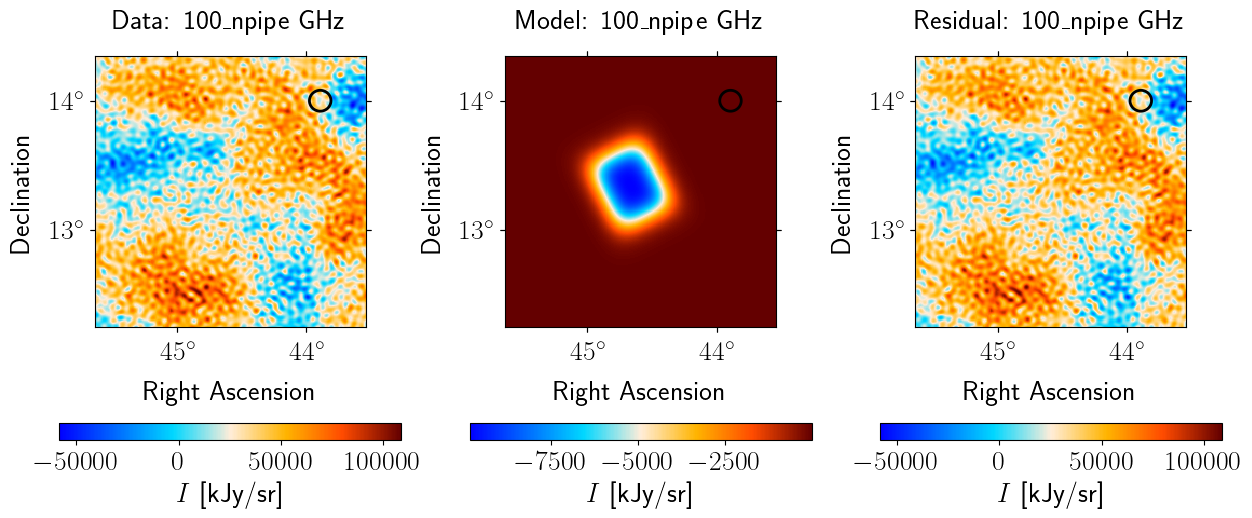

Saving maps for 100_npipe GHz


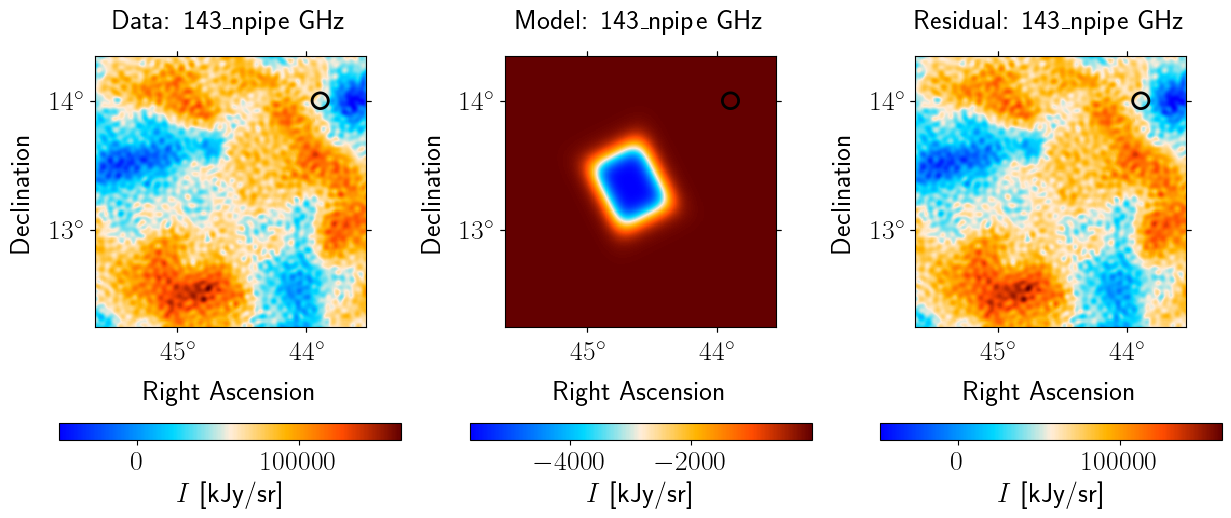

Saving maps for 143_npipe GHz


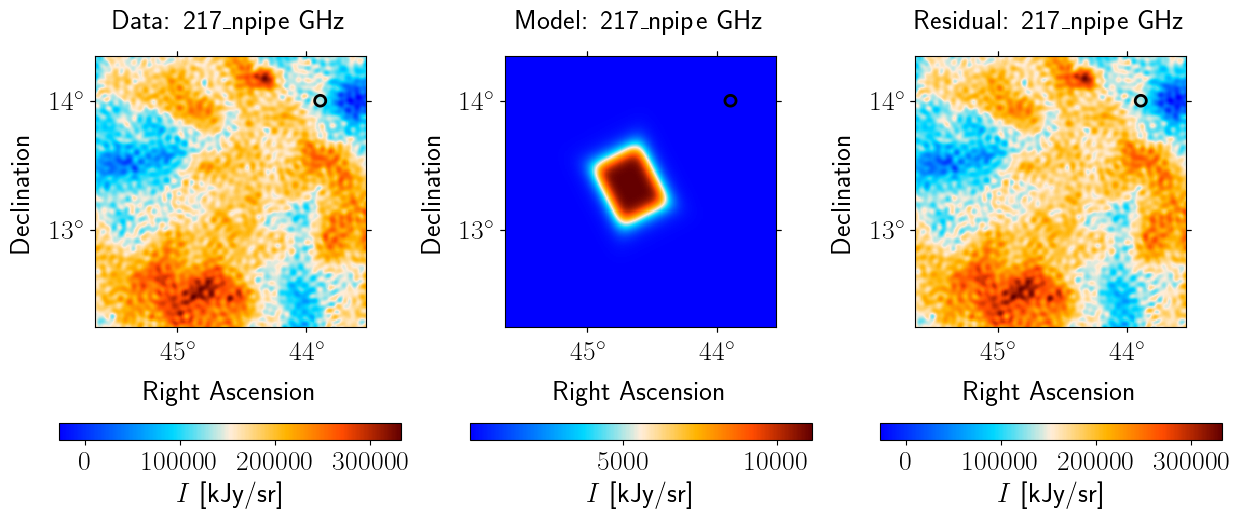

Saving maps for 217_npipe GHz


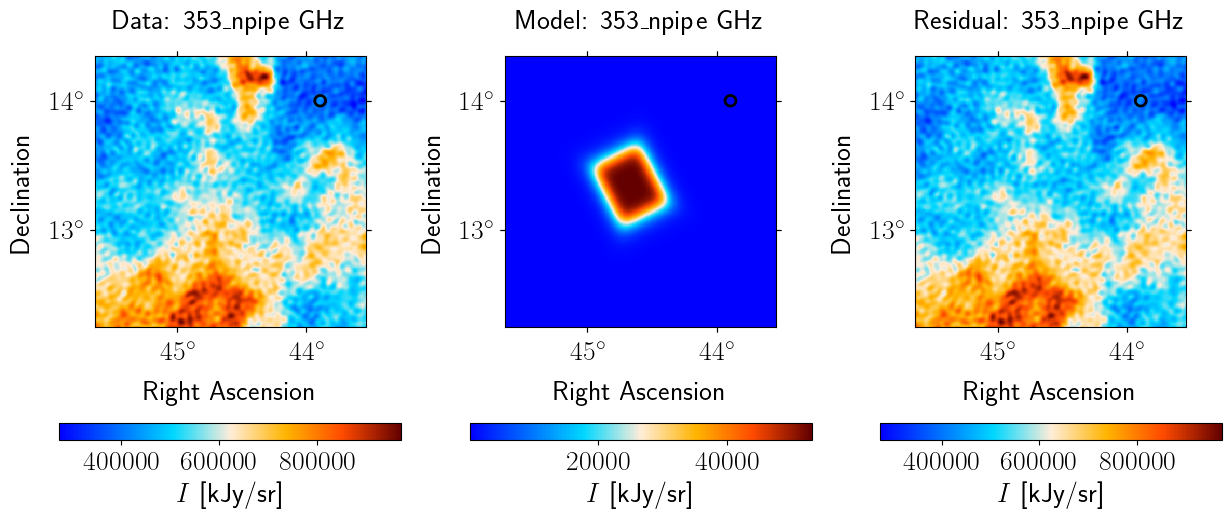

Saving maps for 353_npipe GHz


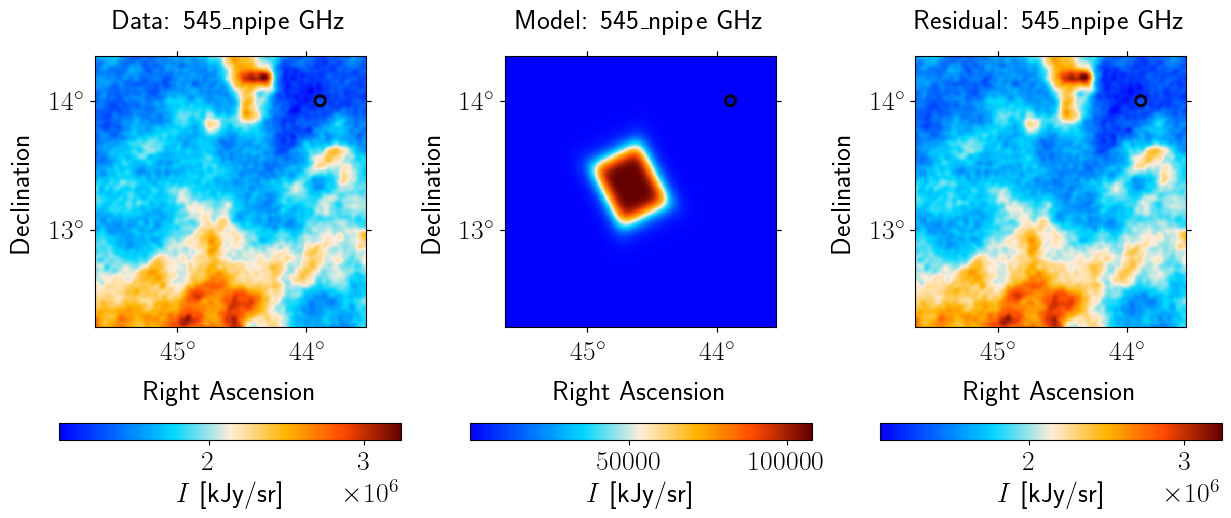

Saving maps for 545_npipe GHz


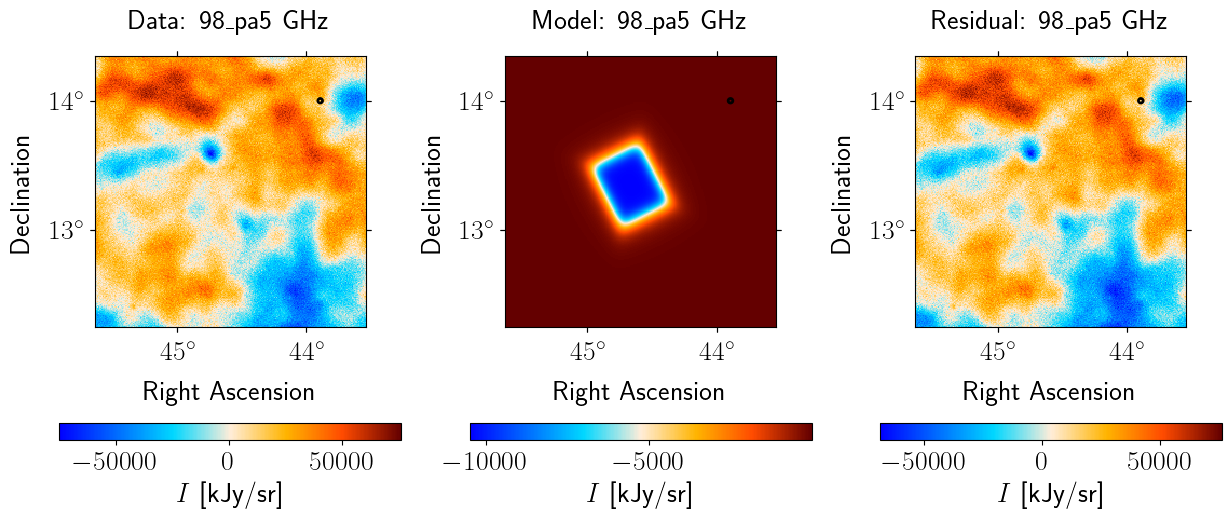

Saving maps for 98_pa5 GHz


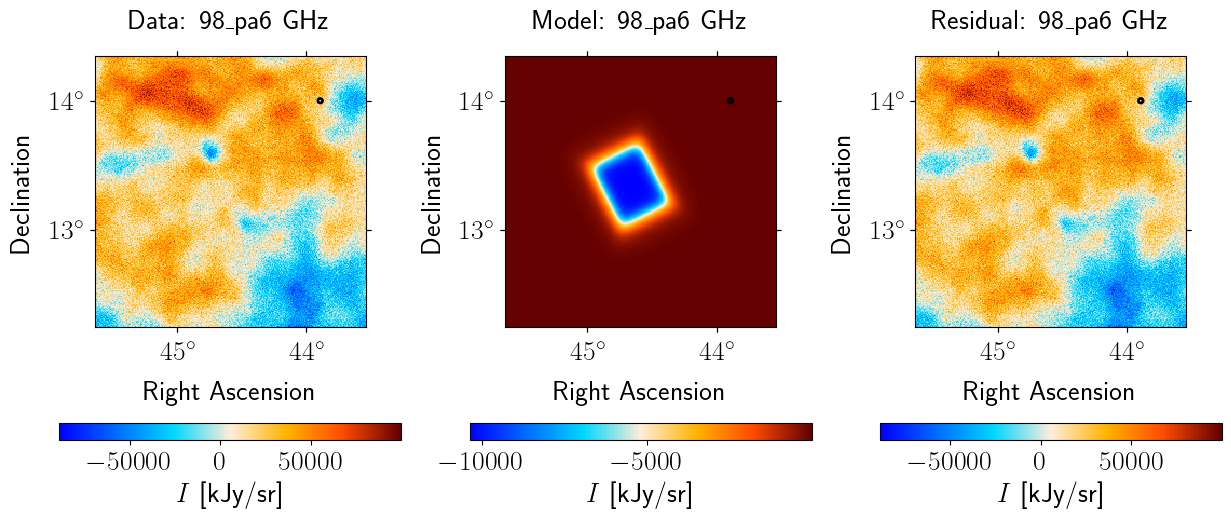

Saving maps for 98_pa6 GHz


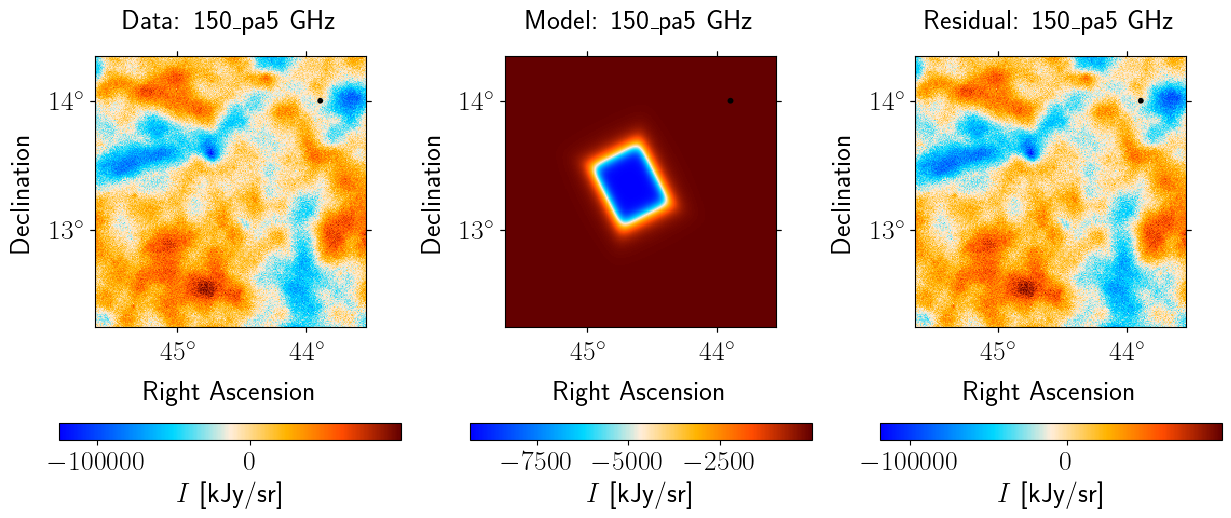

Saving maps for 150_pa5 GHz


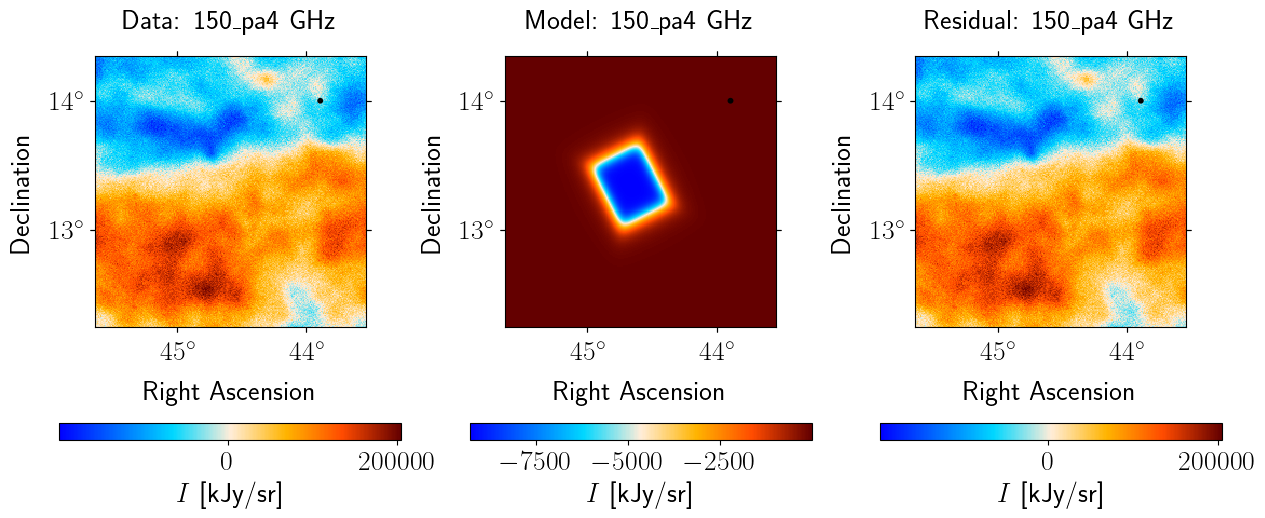

Saving maps for 150_pa4 GHz


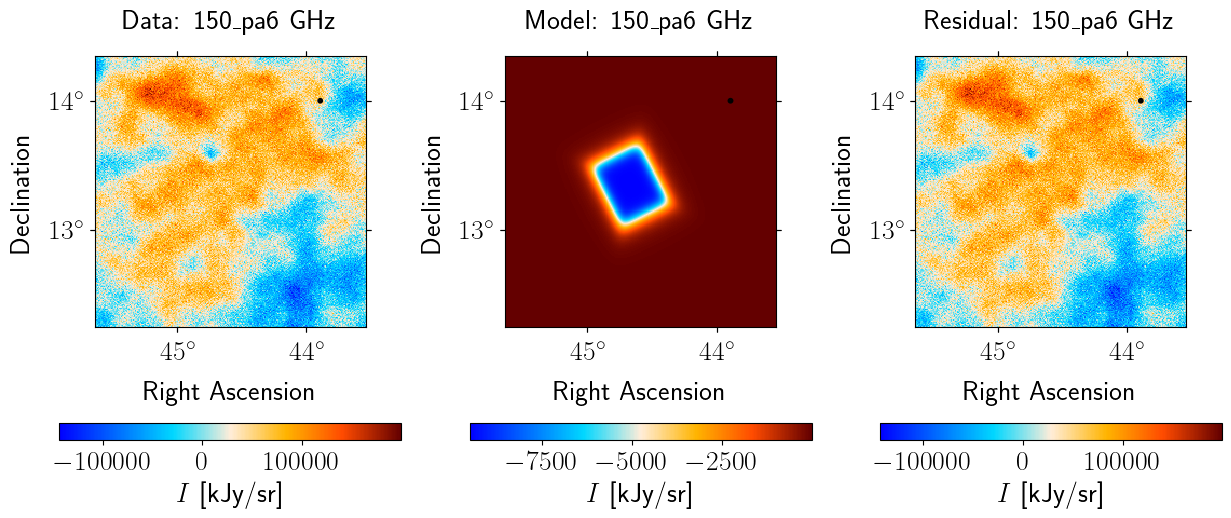

Saving maps for 150_pa6 GHz


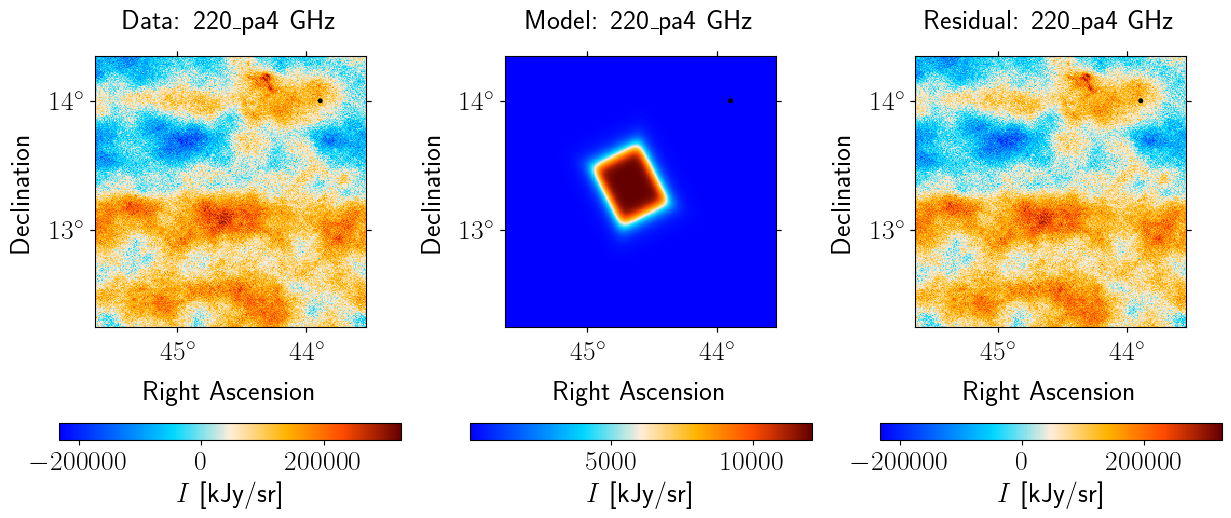

Saving maps for 220_pa4 GHz


In [7]:
labels = [r'$RA_{\rm A401}$', 
            r'$DEC_{\rm A401}$', 
            r'$\beta_{\rm A401}$', 
            r'$r_{\rm c, A401}$ [$^{\prime}$]', 
            r'$e_{\rm A401}$', 
            r'$\theta_{\rm A401}$', 
            r'$\tau_{\rm A401}$', 
            r'$T_{\rm e, A401}$', 
            r'$A_{\rm D, A401}$',
            r"$v_{r, A401}$",
            
            r'$RA_{\rm A399}$', 
            r'$DEC_{\rm A399}$', 
            r'$\beta_{\rm A399}$', 
            r'$r_{\rm c, A399}$ [$^{\prime}$]', 
            r'$e_{\rm A399}$', 
            r'$\theta_{\rm A399}$', 
            r'$\tau_{\rm A399}$', 
            r'$T_{\rm e, A399}$', 
            r'$A_{\rm D, A399}$',
            r"$v_{r, A399}$",

            r"$RA_{\rm fil}$",
            r"$DEC_{\rm fil}$",
            r"$L_{\rm fil}$",
            r"$W_{\rm fil}$",
            r'$\tau_{\rm fil}$',
            r'$T_{\rm e, fil}$',
            r'$A_{\rm D, fil}$',
            
            r"$v_{r, fil}$"]

labels_no_tex = [
    "RA_A401",
    "DEC_A401",
    "beta_A401",
    "r_c_A401 [']",
    "e_A401",
    "theta_A401",
    "tau_A401",
    "T_e_A401",
    "A_D_A401",
    
    "RA_A399",
    "DEC_A399",
    "beta_A399",
    "r_c_A399 [']",
    "e_A399",
    "theta_A399",
    "tau_A399",
    "T_e_A399",
    "A_D_A399",
    
    "RA_fil",
    "DEC_fil",
    "L_fil",
    "W_fil",
    "tau_fil",
    "T_e_fil",
    "A_D_fil",
    
    "v_r_avg"
]

config = "/home/gill/research/ACT/multi-freq-bridge/configs/case23_ajay.yaml"
chain = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case23/chain.h5"


_ = map_maker_improved(mcmc_fname=chain,
                       cf_name=config,
                       labels=labels,
                       labels_no_tex=labels_no_tex,
                       burnin=70000,
                       thin=1, 
                       plot_converge=False,
                       plot_samples=0)


In [ ]:
labels = [r'$RA_{\rm A401}$', 
            r'$DEC_{\rm A401}$', 
            r'$\beta_{\rm A401}$', 
            r'$r_{\rm c, A401}$ [$^{\prime}$]', 
            r'$e_{\rm A401}$', 
            r'$\theta_{\rm A401}$', 
            r'$\tau_{\rm A401}$', 
            r'$T_{\rm e, A401}$', 
            r'$A_{\rm D, A401}$',
            r"$v_{r, A401}$",
            
            r'$RA_{\rm A399}$', 
            r'$DEC_{\rm A399}$', 
            r'$\beta_{\rm A399}$', 
            r'$r_{\rm c, A399}$ [$^{\prime}$]', 
            r'$e_{\rm A399}$', 
            r'$\theta_{\rm A399}$', 
            r'$\tau_{\rm A399}$', 
            r'$T_{\rm e, A399}$', 
            r'$A_{\rm D, A399}$',
            r"$v_{r, A399}$",

            r"$RA_{\rm fil}$",
            r"$DEC_{\rm fil}$",
            r"$L_{\rm fil}$",
            r"$W_{\rm fil}$",
            r'$\tau_{\rm fil}$',
            r'$T_{\rm e, fil}$',
            r'$A_{\rm D, fil}$',
            
            r"$v_{r, fil}$"]

labels_no_tex = [
    "RA_A401",
    "DEC_A401",
    "beta_A401",
    "r_c_A401 [']",
    "e_A401",
    "theta_A401",
    "tau_A401",
    "T_e_A401",
    "A_D_A401",
    
    "RA_A399",
    "DEC_A399",
    "beta_A399",
    "r_c_A399 [']",
    "e_A399",
    "theta_A399",
    "tau_A399",
    "T_e_A399",
    "A_D_A399",
    
    "RA_fil",
    "DEC_fil",
    "L_fil",
    "W_fil",
    "tau_fil",
    "T_e_fil",
    "A_D_fil",
    
    "v_r_avg"
]

config = "/home/gill/research/ACT/multi-freq-bridge/configs/case23_ajay.yaml"
chain = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case23/chain.h5"


_ = map_maker_improved_fullSize(mcmc_fname=chain,
                       cf_name=config,
                       labels=labels,
                       labels_no_tex=labels_no_tex,
                       burnin=50000,
                       thin=1, 
                       plot_converge=False,
                       plot_samples=0)
